The project focuses on analyzing textual music reviews from the Pitchfork website, which are used to evaluate music albums on a scale from 0 to 10. These reviews contain both factual information (such as artist names, music genres, instruments, and dates) and subjective opinions. The main goal of the project is to determine whether it is possible to predict, based only on the review text, whether a review is positive (score ≥ 7) or negative (score < 7). Additionally, the project aims to predict the exact numerical score assigned to a review using regression. The project combines methods from Information Extraction, Natural Language Processing, and Machine Learning.

The predictive pipeline uses `CountVectorizer` (bag-of-words counts) without manual feature filtering, delegating variable selection to LASSO regularization. Sentiment features are derived from a pre-trained transformer model (DistilBERT fine-tuned on SST-2) applied in a zero-shot transfer setting. Model interpretability is supported through Explainable AI (XAI) analysis of LASSO coefficients, which directly reveal the tokens most associated with higher or lower scores.

The dataset of Pitchfork music reviews used in this project was obtained from the public Kaggle repository at https://www.kaggle.com/datasets/nolanbconaway/pitchfork-data, which contains review text, album metadata, and associated scores.

Author: Antoni Rozbicki

# 1. Loading and inspecting Pitchfork Reviews dataset

In the first step, the data were loaded from an SQLite database containing review metadata (author, publication date, score) and the full textual content of the reviews, and the relevant tables were joined to obtain a complete dataset. At this stage, basic data inspection was performed, including analysis of missing values, the distribution of scores, and the display of sample reviews. The goal of this step was to understand the data structure and the characteristics of the targetted variable.

In [3]:
import sqlite3
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 300)

DB_PATH = "database.sqlite"

# Connect to the SQLite database and load reviews with their full text
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql(
        """
        SELECT
            r.reviewid,
            r.title,
            r.artist,
            r.url,
            r.score,
            r.best_new_music,
            r.author,
            r.author_type,
            r.pub_date,
            r.pub_year,
            c.content AS review_text
        FROM reviews r
        LEFT JOIN content c
            ON r.reviewid = c.reviewid
        """,
        conn
    )

# Convert publication date to datetime for easier filtering and plotting later
df["pub_date"] = pd.to_datetime(df["pub_date"], errors="coerce")

# Basic dataset overview
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values per column:")
print(df.isna().sum())

# Inspect the target variable (review score)
print("\nScore distribution:")
print(df["score"].describe())

# Display a few random examples (text is shortened for readability)
sample = df.sample(5, random_state=42).copy()
sample["review_text_preview"] = (
    sample["review_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 500)
)

sample[[
    "reviewid",
    "pub_date",
    "artist",
    "title",
    "score",
    "best_new_music",
    "review_text_preview"
]]


Dataset shape: (18401, 11)

Columns:
['reviewid', 'title', 'artist', 'url', 'score', 'best_new_music', 'author', 'author_type', 'pub_date', 'pub_year', 'review_text']

Missing values per column:
reviewid             0
title                0
artist               0
url                  0
score                0
best_new_music       0
author               0
author_type       3910
pub_date             0
pub_year             0
review_text          0
dtype: int64

Score distribution:
count    18401.000000
mean         7.005907
std          1.293507
min          0.000000
25%          6.400000
50%          7.200000
75%          7.800000
max         10.000000
Name: score, dtype: float64


,reviewid,pub_date,artist,title,score,best_new_music,review_text_preview
8132,13895,2010-02-18,everybody was in the french resistance...now!,"fixin' the charts, vol. 1",3.8,0,"""Answer records are not new,"" Time magazine wrote. That was in 1961. From ""Yes, I'm Lonesome Tonight"" to ""You Know I'll Love You Tomorrow"", ""Roll With Me, Henry"" to ""Wearing His Rolex"", songs that respond to other songs have long been a lively pop tradition. In 1995, German reissue label Bear Fa..."
4115,18168,2013-07-11,ryksopp,late night tales,7.4,0,"In its second decade of existence, Late Night Tales is an institution. The compilation series asks artists to create their ultimate ""late night"" mix and has featured a variety of acts, from MGMT to Belle & Sebastian to Four Tet, Jamiroquai, and Lindstrøm. The line-up's been so diverse, it's inte..."
15369,417,2004-01-08,apparat,duplex,7.3,0,"Music criticism (and listening for that matter) is never an exact art. As context shifts, so too does a record's resonance and weight-- looking back at 2003, I couldn't help considering which albums I had under- or overrated. Among those that I listen to more often now than I had thought I would..."
8241,13833,2010-01-19,underworld vs. the misterons,athens,4.9,0,"Underworld like records. And not just records, mind you, but an eclectic array of records not entirely composed with sequencers and drum machines. Such seems to be the message of Athens, the new full-length compilation put together by the 1990s dance music figureheads. A spattering of jazz, tech..."
17614,346,2001-09-24,atombombpocketknife,god save the abpk,6.6,0,"I used to work at a shockingly lame magazine in Miami Beach, Florida, which will remain unnamed. A couple of years before I became employed there, a prankster with a morbid bent sent their offices a plain envelope with a note enclosed informing the unlucky recipient that he/she had just been exp..."


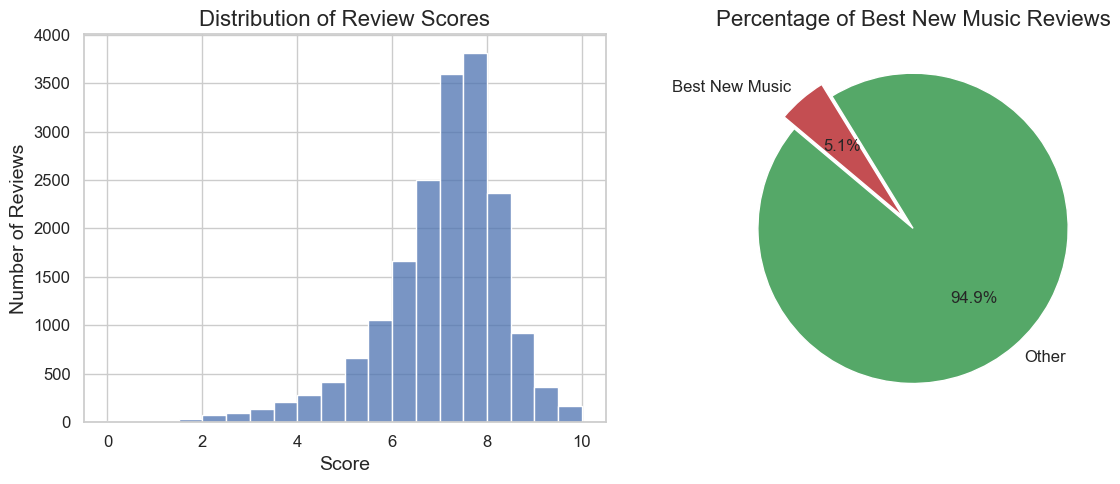

In [4]:
# Visualization - distribution of review scores and Best New Music share

import matplotlib.pyplot as plt
import seaborn as sns

# Set global plotting style for consistency
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

# Histogram showing the distribution of review scores
plt.subplot(1, 2, 1)
sns.histplot(df["score"], bins=20, kde=False, color="#4C72B0")
plt.title("Distribution of Review Scores")
plt.xlabel("Score")
plt.ylabel("Number of Reviews")

# Pie chart showing the proportion of Best New Music reviews
plt.subplot(1, 2, 2)
best_new_counts = df["best_new_music"].value_counts().sort_index()
plt.pie(
    best_new_counts,
    labels=["Other", "Best New Music"],
    autopct="%1.1f%%",
    startangle=140,
    colors=["#55A868", "#C44E52"],
    explode=(0, 0.1),
    textprops={"fontsize": 12}
)
plt.title("Percentage of Best New Music Reviews")

plt.tight_layout()
plt.show()


# 2. Text preprocessing and cleaning

This stage is crucial for further analysis and is responsible for preparing the text for Information Extraction and Machine Learning methods. The processing steps included removing HTML artifacts, normalizing whitespace and characters, sentence segmentation, word tokenization, lemmatization, and stopword removal. Two parallel approaches were applied: sentence-level tokenization for sequential modeling (CRF) and linear tokenization for vector-based methods (bag-of-words), along with diagnostics of text length and sentence counts.

In [5]:
import re
import html
import unicodedata
import nltk

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# If needed, uncomment once to download required NLTK resources
# nltk.download("punkt")
# nltk.download("stopwords")
# nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def basic_clean(text: str) -> str:
    """Light cleaning: remove HTML artifacts and normalize whitespace."""
    if text is None:
        return ""
    text = html.unescape(str(text))
    text = unicodedata.normalize("NFKC", text)          # normalize unicode (quotes, dashes, spaces)
    text = re.sub(r"<[^>]+>", " ", text)                # remove HTML tags
    text = re.sub(r"\s+", " ", text).strip()            # collapse whitespace
    return text

def tokenize_for_crf(text: str) -> list[list[str]]:
    """Sentence + word tokenization for sequence labeling (CRF)."""
    sentences = sent_tokenize(text)
    return [word_tokenize(sent) for sent in sentences]

def tokenize_for_ml(text: str) -> list[str]:
    """Tokenization for vector-based models (bag-of-words)."""
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha()]          # keep only alphabetic tokens
    tokens = [t for t in tokens if t not in stop_words]  # remove stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens]   # lemmatize
    return tokens

# Clean raw review text
df = df.copy()
df["text_clean"] = df["review_text"].map(basic_clean)

# Build two token views: sentence-level (CRF) and flat tokens (ML)
df["sentences_tokens"] = df["text_clean"].map(tokenize_for_crf)
df["ml_tokens"] = df["text_clean"].map(tokenize_for_ml)

# Basic diagnostics of sentence and token counts
df["n_sentences"] = df["sentences_tokens"].map(len)
df["n_ml_tokens"] = df["ml_tokens"].map(len)

print("Sentence count statistics:")
print(df["n_sentences"].describe())

print("\nML token count statistics:")
print(df["n_ml_tokens"].describe())

# Show a few examples for sanity checking
preview = df.sample(5, random_state=42).copy()
preview["sentences_preview"] = preview["sentences_tokens"].map(lambda x: x[0][:15] if x else [])
preview["ml_tokens_preview"] = preview["ml_tokens"].map(lambda x: x[:20])

preview[[
    "reviewid",
    "artist",
    "title",
    "score",
    "best_new_music",
    "sentences_preview",
    "ml_tokens_preview"
]]


Sentence count statistics:
count    18401.000000
mean        23.553176
std         10.152517
min          0.000000
25%         17.000000
50%         21.000000
75%         28.000000
max        142.000000
Name: n_sentences, dtype: float64

ML token count statistics:
count    18401.000000
mean       353.490354
std        123.338437
min          0.000000
25%        274.000000
50%        330.000000
75%        404.000000
max       2032.000000
Name: n_ml_tokens, dtype: float64


,reviewid,artist,title,score,best_new_music,sentences_preview,ml_tokens_preview
8132,13895,everybody was in the french resistance...now!,"fixin' the charts, vol. 1",3.8,0,"[``, Answer, records, are, not, new, ,, '', Time, magazine, wrote, .]","[answer, record, new, time, magazine, wrote, yes, lonesome, tonight, know, love, tomorrow, roll, henry, wearing, rolex, song, respond, song, long]"
4115,18168,ryksopp,late night tales,7.4,0,"[In, its, second, decade, of, existence, ,, Late, Night, Tales, is, an, institution, .]","[second, decade, existence, late, night, tale, institution, compilation, series, asks, artist, create, ultimate, late, night, mix, featured, variety, act, mgmt]"
15369,417,apparat,duplex,7.3,0,"[Music, criticism, (, and, listening, for, that, matter, ), is, never, an, exact, art, .]","[music, criticism, listening, matter, never, exact, art, context, shift, record, resonance, weight, looking, back, could, help, considering, album, overrated, among]"
8241,13833,underworld vs. the misterons,athens,4.9,0,"[Underworld, like, records, .]","[underworld, like, record, record, mind, eclectic, array, record, entirely, composed, sequencer, drum, machine, seems, message, athens, new, compilation, put, together]"
17614,346,atombombpocketknife,god save the abpk,6.6,0,"[I, used, to, work, at, a, shockingly, lame, magazine, in, Miami, Beach, ,, Florida, ,]","[used, work, shockingly, lame, magazine, miami, beach, florida, remain, unnamed, couple, year, became, employed, prankster, morbid, bent, sent, office, plain]"


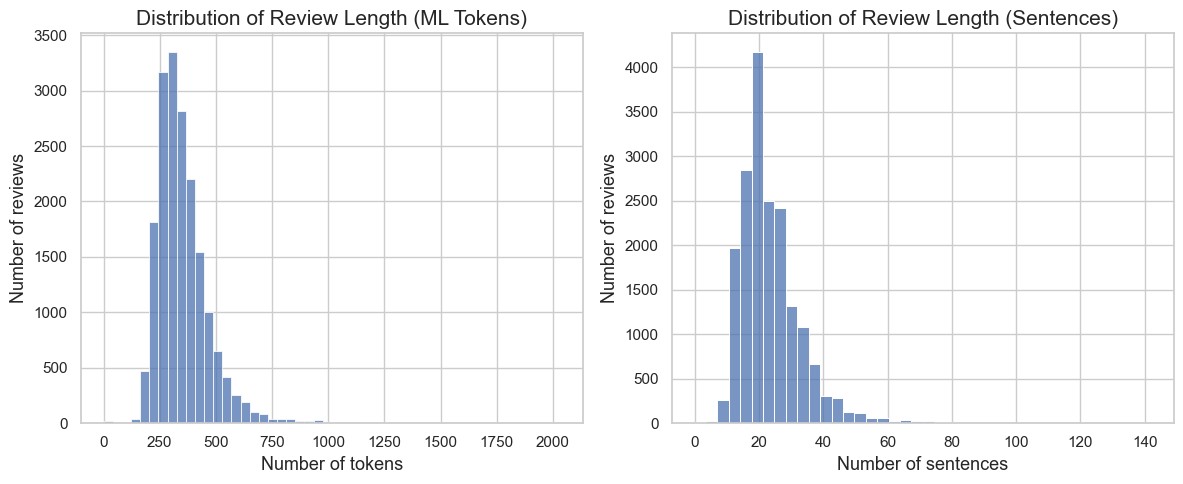

In [6]:
# Visualization - review length distributions 

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 13

# Create side-by-side histograms to compare length measures
fig, axes = plt.subplots(1, 2)

# Review length measured as the number of ML tokens
sns.histplot(df["n_ml_tokens"], bins=50, ax=axes[0], kde=False)
axes[0].set_title("Distribution of Review Length (ML Tokens)")
axes[0].set_xlabel("Number of tokens")
axes[0].set_ylabel("Number of reviews")

# Review length measured as the number of sentences
sns.histplot(df["n_sentences"], bins=40, ax=axes[1], kde=False)
axes[1].set_title("Distribution of Review Length (Sentences)")
axes[1].set_xlabel("Number of sentences")
axes[1].set_ylabel("Number of reviews")

plt.tight_layout()
plt.show()


# 3. Information Extraction using Sequence Modelling (CRF)

The information extraction task relies on a fixed set of entity types and a set of annotation guidelines
that define what should and should not be labelled. These guidelines are designed to be simple and
consistent with the surface-level nature of silver annotations.

**ARTIST**
- Includes names of musical artists and bands.
- Multi-word artist names are annotated as a single entity.
- Album titles and song titles are not annotated as ARTIST.

**GENRE**
- Includes established music genres and stylistic categories.
- Both single-word and multi-word genre expressions are allowed.
- Adjectival style descriptors not referring to a genre (e.g. *dark*, *melodic*) are excluded.

**INSTRUMENT**
- Includes names of musical instruments.
- Generic references to sound (e.g. *noise*, *sound*) are excluded.

**TECHNIQUE**
- Includes production techniques and stylistic terms used to describe how music is made or processed
  (e.g. *lo-fi*, *distorted*, *layered*).
- Genre-like terms are excluded if they primarily describe musical category rather than technique.

**DATE**
- Includes years and month names referring to time periods or release dates.
- Relative expressions (e.g. *recently*, *last year*) are excluded.

**BIO examples**

Sentence: *Hot Chip play lo-fi electronic music released in 2006.*

Hot B-ARTIST
Chip I-ARTIST
play O
lo-fi B-TECHNIQUE
electronic B-GENRE
music O
released O
in O
2006 B-DATE

### 3.1 Preparing data for sequence labelling

In [ ]:
def token_features(sentence, i):
    """Extract CRF features for the token at position i in a tokenized sentence."""
    token = sentence[i]

    features = {
        "bias": 1.0,
        "token.lower": token.lower(),
        "token.isupper": token.isupper(),
        "token.istitle": token.istitle(),
        "token.isdigit": token.isdigit(),
        "prefix-2": token[:2],
        "prefix-3": token[:3],
        "suffix-2": token[-2:],
        "suffix-3": token[-3:],
    }

    # Add previous token features 
    if i > 0:
        prev = sentence[i - 1]
        features.update({
            "-1:token.lower": prev.lower(),
            "-1:token.istitle": prev.istitle(),
            "-1:token.isupper": prev.isupper(),
        })
    else:
        features["BOS"] = True

    # Add next token features
    if i < len(sentence) - 1:
        nxt = sentence[i + 1]
        features.update({
            "+1:token.lower": nxt.lower(),
            "+1:token.istitle": nxt.istitle(),
            "+1:token.isupper": nxt.isupper(),
        })
    else:
        features["EOS"] = True

    return features

def sentence_to_features(sentence):
    """Convert a tokenized sentence into a list of per-token feature dictionaries."""
    return [token_features(sentence, i) for i in range(len(sentence))]

### 3.2 Silver labelling (rule-based pseudo-annotations)

Since the dataset does not contain manually annotated named entities, silver labels are generated using
rule-based heuristics and domain-specific dictionaries.

The following resources and rules are used:

- **ARTIST, GENRE** - extracted from Pitchfork metadata tables.
- **INSTRUMENT, TECHNIQUE** - manually curated domain lexicons.
- **DATE** - detected using regular expressions for years (1900-2099) and a list of month names.

Tokens are normalised before matching (lowercasing and punctuation removal). Labelling is performed after
tokenisation and without lemmatisation.

Typical sources of noise include:
- false positives caused by ambiguous words (e.g. *May* as a verb vs month),
- album titles misclassified as artist names,
- incomplete coverage of multi-word genre expressions.

These silver labels provide a noisy but scalable approximation suitable for training sequence models.


In [8]:
# 3.2 Silver labelling (rule-based pseudo-annotations)

from collections import Counter

# Load genre and artist dictionaries from the SQLite database
with sqlite3.connect(DB_PATH) as conn:
    genres_df = pd.read_sql("SELECT DISTINCT genre FROM genres;", conn)
    artists_df = pd.read_sql("SELECT DISTINCT artist FROM artists;", conn)

GENRE_SET = set(genres_df["genre"].dropna().astype(str).str.lower())
ARTIST_SET = set(artists_df["artist"].dropna().astype(str).str.lower())

# Small domain lexicons (seed lists)
INSTRUMENTS = {
    "guitar", "bass", "drums", "piano", "synth", "synthesizer", "keyboard",
    "violin", "cello", "saxophone", "trumpet", "flute", "banjo"
}

TECHNIQUES = {
    "lo-fi", "lofi", "distorted", "layered", "sampling", "looping",
    "reverb", "autotune", "ambient", "glitch"
}

MONTHS = {
    "january","february","march","april","may","june","july","august",
    "september","october","november","december"
}

YEAR_RE = re.compile(r"^(19\d{2}|20\d{2})$")

def normalize_token(token: str) -> str:
    """Lowercase and strip punctuation from token boundaries."""
    token = token.lower()
    token = re.sub(r"^[^\w]+|[^\w]+$", "", token)
    return token

def init_labels(tokens):
    """Initialize BIO labels as 'O' for the whole sentence."""
    return ["O"] * len(tokens)

def apply_bio(labels, start, end, tag):
    """Apply BIO tags to a token span [start, end)."""
    labels[start] = f"B-{tag}"
    for i in range(start + 1, end):
        labels[i] = f"I-{tag}"

def find_phrase_spans(tokens, phrase_set, max_len=6):
    """Find longest matching multi-token phrases using greedy matching."""
    norm = [normalize_token(t) for t in tokens]
    spans = []
    i = 0
    while i < len(tokens):
        best = None
        for L in range(min(max_len, len(tokens) - i), 0, -1):
            phrase = " ".join(norm[i:i+L]).strip()
            if phrase in phrase_set:
                best = (i, i + L)
                break
        if best:
            spans.append(best)
            i = best[1]
        else:
            i += 1
    return spans

# Use multi-word entries for phrase matching (reduces false positives for single tokens)
ARTIST_MULTIWORD = {a for a in ARTIST_SET if " " in a}
GENRE_MULTIWORD = {g for g in GENRE_SET if " " in g}

def label_sentence(tokens):
    """Assign silver BIO labels to a tokenized sentence."""
    labels = init_labels(tokens)

    # DATE: mark month names and 4-digit years as DATE tokens
    for i, t in enumerate(tokens):
        nt = normalize_token(t)
        if nt in MONTHS or YEAR_RE.match(nt):
            labels[i] = "B-DATE"

    # ARTIST: apply multi-word phrase matching first
    for start, end in find_phrase_spans(tokens, ARTIST_MULTIWORD, max_len=6):
        if all(labels[i] == "O" for i in range(start, end)):
            apply_bio(labels, start, end, "ARTIST")

    # GENRE: apply multi-word phrase matching (e.g., "black metal")
    for start, end in find_phrase_spans(tokens, GENRE_MULTIWORD, max_len=4):
        if all(labels[i] == "O" for i in range(start, end)):
            apply_bio(labels, start, end, "GENRE")

    # GENRE: fall back to single-token dictionary matches
    for i, t in enumerate(tokens):
        if labels[i] == "O" and normalize_token(t) in GENRE_SET:
            labels[i] = "B-GENRE"

    # INSTRUMENT: single-token lexicon match
    for i, t in enumerate(tokens):
        if labels[i] == "O" and normalize_token(t) in INSTRUMENTS:
            labels[i] = "B-INSTRUMENT"

    # TECHNIQUE: single-token lexicon match
    for i, t in enumerate(tokens):
        if labels[i] == "O" and normalize_token(t) in TECHNIQUES:
            labels[i] = "B-TECHNIQUE"

    return labels

# Prepare CRF training sequences (limited for computational cost)
X, y, SENTS = [], [], []

MAX_DOCS = 5000
docs = df["sentences_tokens"].iloc[:MAX_DOCS]

for doc in docs:
    for sent in doc:
        if len(sent) < 3:
            continue
        SENTS.append(sent)
        X.append(sentence_to_features(sent))
        y.append(label_sentence(sent))

print("Prepared sequences:", len(X))

# Inspect token-level label distribution
label_counts = Counter(lab for seq in y for lab in seq)
label_dist = (
    pd.DataFrame(label_counts.items(), columns=["label", "count"])
    .sort_values("count", ascending=False)
)
label_dist["share"] = label_dist["count"] / label_dist["count"].sum()
display(label_dist.head(15))

# Show a few labeled examples (sentences with at least one non-O tag)
non_o_idx = [i for i, seq in enumerate(y) if any(l != "O" for l in seq)]
preview_idx = pd.Series(non_o_idx).sample(min(5, len(non_o_idx)), random_state=42)

for idx in preview_idx:
    pairs = list(zip(SENTS[idx][:30], y[idx][:30]))
    print(pairs)
    print()


Prepared sequences: 116913


,label,count,share
0,O,4166789,0.968389
2,I-ARTIST,64776,0.015054
1,B-ARTIST,37680,0.008757
3,B-DATE,12062,0.002803
6,B-INSTRUMENT,10018,0.002328
5,B-GENRE,9536,0.002216
4,B-TECHNIQUE,1943,0.000452


[('She', 'O'), ('was', 'O'), ('reflecting', 'O'), ('on', 'O'), ('the', 'O'), ('trial', 'O'), ('of', 'O'), ('Pussy', 'B-ARTIST'), ('Riot', 'I-ARTIST'), (',', 'I-ARTIST'), ('who', 'O'), ('cite', 'O'), ('Bikini', 'B-ARTIST'), ('Kill', 'I-ARTIST'), ('as', 'O'), ('a', 'O'), ('major', 'O'), ('influence', 'O'), (',', 'O'), ('but', 'O'), ('she', 'O'), ('might', 'O'), ('as', 'O'), ('well', 'O'), ('have', 'O'), ('been', 'O'), ('summing', 'O'), ('up', 'O'), ('the', 'O'), ('spirit', 'O')]

[('The', 'O'), ('guitar', 'B-INSTRUMENT'), ('work', 'O'), (',', 'O'), ('courtesy', 'O'), ('of', 'O'), ('co-frontmen', 'O'), ('Savage', 'O'), ('and', 'O'), ('Austin', 'O'), ('Brown', 'O'), (',', 'O'), ('is', 'O'), ('clever', 'O'), ('and', 'O'), ('accomplished', 'O'), ('without', 'O'), ('being', 'O'), ('too', 'O'), ('showy', 'O'), (';', 'O'), ('in', 'O'), ('their', 'O'), ('hands', 'O'), (',', 'B-ARTIST'), ('the', 'I-ARTIST'), ('instruments', 'I-ARTIST'), ('squeak', 'O'), (',', 'O'), ('saunter', 'O')]

[('But', 'O'

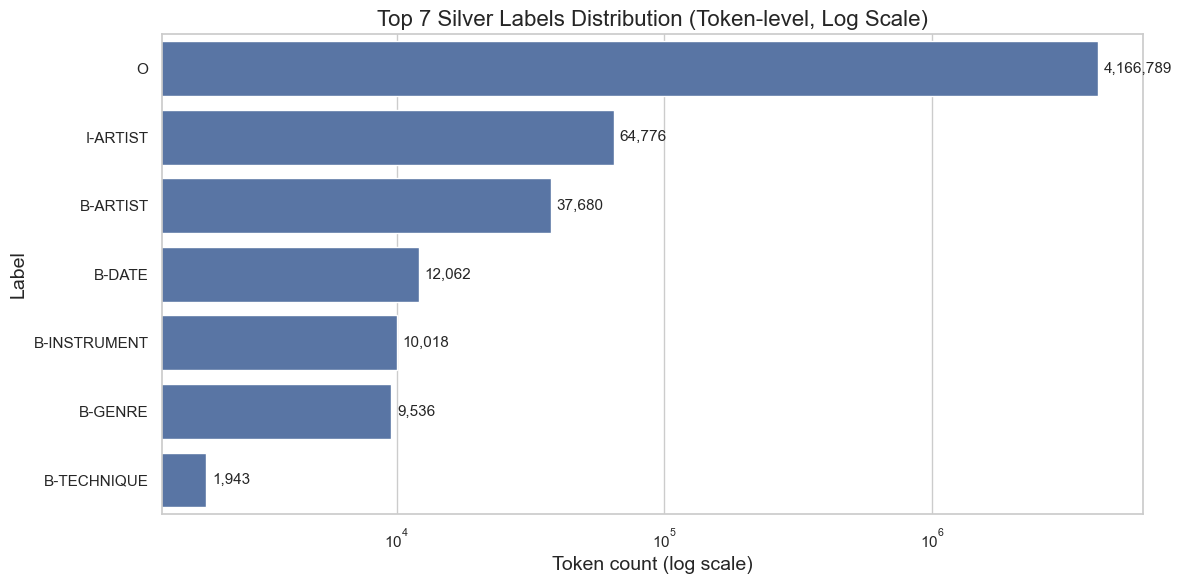

In [9]:
# Visualization - label distribution (token-level, log scale)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Plot the most frequent labels (log scale is used due to strong imbalance)
top_labels = label_dist.head(7)

ax = sns.barplot(
    data=top_labels,
    y="label",
    x="count"
)

ax.set_xscale("log")

# Add count labels to bars for readability
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width * 1.05,
        p.get_y() + p.get_height() / 2,
        f"{int(width):,}",
        va="center",
        fontsize=11
    )

plt.title("Top 7 Silver Labels Distribution (Token-level, Log Scale)", fontsize=16)
plt.xlabel("Token count (log scale)", fontsize=14)
plt.ylabel("Label", fontsize=14)

plt.tight_layout()
plt.show()


### 3.3 Training CRF

In [10]:
# If needed (first time only):
# !pip install sklearn-crfsuite


In [ ]:
import random
import numpy as np
import sklearn_crfsuite
from sklearn.model_selection import train_test_split
from sklearn_crfsuite import metrics

# Build sentence-level sequences together with review IDs (needed for document-level split)
X_all, y_all, reviewid_all = [], [], []

docs = df[["reviewid", "sentences_tokens"]] 

for rid, doc_sents in zip(docs["reviewid"].values, docs["sentences_tokens"].values):
    for sent in doc_sents:
        if len(sent) < 3:
            continue
        reviewid_all.append(rid)
        X_all.append(sentence_to_features(sent))
        y_all.append(label_sentence(sent))

reviewid_all = np.array(reviewid_all)

# Split by unique review IDs to avoid having sentences from the same review in both sets
unique_rids = np.unique(reviewid_all)
train_rids, test_rids = train_test_split(unique_rids, test_size=0.2, random_state=42)

train_mask = np.isin(reviewid_all, train_rids)
test_mask = np.isin(reviewid_all, test_rids)

X_train = [x for x, m in zip(X_all, train_mask) if m]
y_train = [yy for yy, m in zip(y_all, train_mask) if m]
X_test  = [x for x, m in zip(X_all, test_mask) if m]
y_test  = [yy for yy, m in zip(y_all, test_mask) if m]

print("Train sentences:", len(X_train), "Test sentences:", len(X_test))
print("Train reviews:", len(train_rids), "Test reviews:", len(test_rids))

# Define and train CRF model
crf = sklearn_crfsuite.CRF(
    algorithm="lbfgs",
    c1=0.1,
    c2=0.1,
    max_iterations=100,
    all_possible_transitions=True
)
crf.fit(X_train, y_train)

# Predict on the test set
y_pred = crf.predict(X_test)

# Evaluate token-level performance excluding the "O" label
labels = sorted({lab for seq in y_test for lab in seq if lab != "O"})

print("Labels (excluding O):", labels)
print("\nToken-level F1 (weighted, excluding O):")
print(metrics.flat_f1_score(y_test, y_pred, average="weighted", labels=labels))

print("\nClassification report (excluding O):")
print(metrics.flat_classification_report(y_test, y_pred, labels=labels, digits=3))

# Show a few qualitative examples (token / silver label / predicted label)
sample_idx = random.sample(range(len(X_test)), min(5, len(X_test)))

for idx in sample_idx:
    tokens = [tok_feats["token.lower"] for tok_feats in X_test[idx]]
    gold = y_test[idx]
    pred = y_pred[idx]

    print("\nToken / SilverLabel / PredLabel (first 30 tokens):")
    for r in zip(tokens[:30], gold[:30], pred[:30]):
        print(r)

Train sentences: 345166 Test sentences: 85698
Train reviews: 14700 Test reviews: 3676
Labels (excluding O): ['B-ARTIST', 'B-DATE', 'B-GENRE', 'B-INSTRUMENT', 'B-TECHNIQUE', 'I-ARTIST']

Token-level F1 (weighted, excluding O):
0.8726331468642515

Classification report (excluding O):
              precision    recall  f1-score   support

    B-ARTIST      0.874     0.819     0.846     26684
      B-DATE      1.000     0.998     0.999      7075
     B-GENRE      0.999     0.998     0.999      6110
B-INSTRUMENT      0.998     0.999     0.998      8223
 B-TECHNIQUE      0.999     0.999     0.999      1460
    I-ARTIST      0.852     0.799     0.825     44895

   micro avg      0.895     0.853     0.874     94447
   macro avg      0.954     0.935     0.944     94447
weighted avg      0.894     0.853     0.873     94447


Token / SilverLabel / PredLabel (first 30 tokens):
('loosening', 'O', 'O')
('their', 'O', 'O')
('ties', 'O', 'O')
('and', 'O', 'O')
('unbuttoning', 'O', 'O')
('their', 'O', 

A CRF model for sequence labelling was trained using weak supervision (silver labels) derived from rule-based heuristics and lexicons. The token-level F1 score (excluding ‘O’) reaches 0.873 on the held-out set, indicating high agreement with the silver annotation rules. Since the evaluation is performed against automatically generated labels rather than human-annotated ground truth, the quantitative results are complemented with qualitative inspection of the extracted entities.

C:\Users\antek\AppData\Local\Temp\ipykernel_1648\2728189120.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


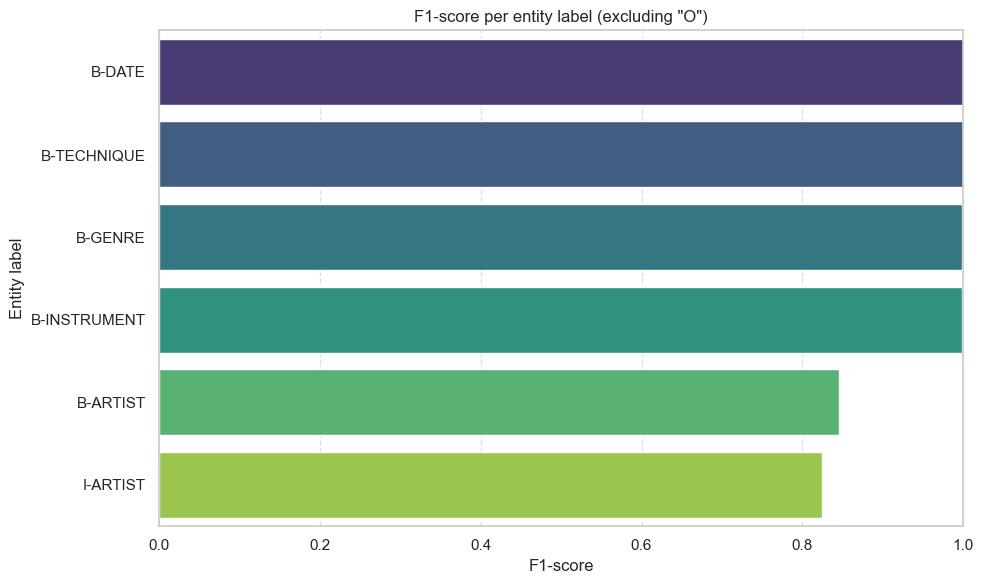

In [ ]:
# Visualization - F1-score per entity label (excluding "O")

def plot_classification_report(y_test, y_pred, labels):
    # Compute classification report as a DataFrame
    report = metrics.flat_classification_report(
        y_test, y_pred, labels=labels, output_dict=True
    )
    df_report = pd.DataFrame(report).transpose()

    # Keep only entity labels and sort by F1-score
    df_labels = df_report.loc[labels].sort_values(by="f1-score", ascending=False)

    # Plot F1-score per label
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=df_labels["f1-score"],
        y=df_labels.index,
        palette="viridis"
    )
    plt.title('F1-score per entity label (excluding "O")')
    plt.xlabel("F1-score")
    plt.ylabel("Entity label")
    plt.xlim(0, 1)
    plt.grid(axis="x", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# Plot F1-scores for CRF predictions
plot_classification_report(y_test, y_pred, labels)

### 3.4 Qualitative evaluation (token -> silver label -> predicted label)

The quantitative evaluation of the CRF model is performed against silver labels generated by heuristics,
not manually verified gold annotations. As a result, reported metrics measure agreement with the rule-based
labelling scheme rather than true extraction accuracy.

While qualitative examples suggest reasonable generalisation beyond the rules, the results should be
interpreted as a proxy evaluation. A more reliable assessment would require a manually annotated gold subset
(e.g. 200 sentences), which is left as future work.


In [ ]:
random.seed(42)

def sentence_has_entity(labels_seq):
    return any(l != "O" for l in labels_seq)

# Select sentences that contain at least one entity (silver or predicted)
candidate_idx = [
    i for i in range(len(X_test))
    if sentence_has_entity(y_test[i]) or sentence_has_entity(y_pred[i])
]

print("Candidate sentences with at least one entity:", len(candidate_idx))

# Sample a few examples for qualitative inspection
n_examples = 5
if len(candidate_idx) == 0:
    print("No candidate sentences found (all predictions and silver labels are 'O').")
else:
    chosen = random.sample(candidate_idx, k=min(n_examples, len(candidate_idx)))

    for j, idx in enumerate(chosen, start=1):
        tokens = [f["token.lower"] for f in X_test[idx]]
        gold = y_test[idx]
        pred = y_pred[idx]

        ex_df = pd.DataFrame({
            "token": tokens,
            "silver_label": gold,
            "pred_label": pred
        })
        ex_df["match"] = ex_df["silver_label"] == ex_df["pred_label"]

        print(f"\nExample {j}:")
        display(ex_df.head(60))

        # Show mismatches for quick error analysis
        mism = ex_df[~ex_df["match"]]
        if len(mism) > 0:
            print("Mismatches (first 30):")
            display(mism.head(30))
        else:
            print("No mismatches in the displayed part.")

Candidate sentences with at least one entity: 34526

Example 1:


,token,silver_label,pred_label,match
0,but,O,O,True
1,have,O,O,True
2,you,O,O,True
3,seen,O,O,True
4,all,O,O,True
5,these,O,O,True
6,decades-old,O,O,True
7,rock,B-GENRE,B-GENRE,True
8,bands,O,O,True
9,",",O,O,True


No mismatches in the displayed part.

Example 2:


,token,silver_label,pred_label,match
0,twenty,O,O,True
1,years,O,O,True
2,in,O,O,True
3,",",O,O,True
4,they,O,O,True
5,’,O,O,True
6,ve,O,O,True
7,finally,O,O,True
8,reconciled,O,O,True
9,the,O,O,True


No mismatches in the displayed part.

Example 3:


...

,token,silver_label,pred_label,match
7,the,O,B-ARTIST,False
8,apples,O,I-ARTIST,False
9,',O,I-ARTIST,False



Example 5:


,token,silver_label,pred_label,match
0,formed,O,O,True
1,in,O,O,True
2,louisville,O,O,True
3,in,O,O,True
4,1978,B-DATE,B-DATE,True
5,",",B-ARTIST,O,False
6,the,I-ARTIST,O,False
7,endtables,I-ARTIST,O,False
8,lasted,O,O,True
9,less,O,O,True


Mismatches (first 30):


,token,silver_label,pred_label,match
5,",",B-ARTIST,O,False
6,the,I-ARTIST,O,False
7,endtables,I-ARTIST,O,False


### Evaluation caveat

The reported IE metrics measure agreement with silver annotations rather than true extraction quality and
should therefore be interpreted as proxy performance, not as an estimate of real-world named entity
recognition accuracy.

# 4. Keyword extraction (YAKE)

In this part, the YAKE algorithm was used to extract keywords from the reviews. The goal was to capture the most important concepts describing each album and to obtain an interpretable representation of the review content. Example keywords for selected reviews were displayed, allowing for a qualitative assessment of the method’s relevance.

In [14]:
# If needed (first time only):
# !python -m pip install yake


In [15]:
import yake

# YAKE configuration
language = "en"
max_ngram_size = 3
deduplication_threshold = 0.9
top_k = 15

kw_extractor = yake.KeywordExtractor(
    lan=language,
    n=max_ngram_size,
    dedupLim=deduplication_threshold,
    top=top_k
)

def extract_keywords(text: str):
    """Extract top keywords using YAKE (return keywords only)."""
    text = "" if text is None else str(text)
    kws = kw_extractor.extract_keywords(text)
    return [kw for kw, score in kws]

# Extract keywords on a subset for speed (set to df to process all reviews)
MAX_DOCS = 5000
df_kw = df.iloc[:MAX_DOCS].copy()

df_kw["yake_keywords"] = df_kw["text_clean"].map(extract_keywords)

# Basic diagnostics
print("Docs with at least 1 keyword:", df_kw["yake_keywords"].map(len).gt(0).sum())
print("Average number of keywords:", df_kw["yake_keywords"].map(len).mean())

# Show examples
examples = df_kw.sample(5, random_state=42)[
    ["reviewid", "artist", "title", "score", "best_new_music", "yake_keywords"]
]
examples


Docs with at least 1 keyword: 4996
Average number of keywords: 14.988


,reviewid,artist,title,score,best_new_music,yake_keywords
1501,21020,donato dozzy,the loud silence,6.9,0,"[Vietnam to Finland, Siberia to Cameroon, century BCE, originated in Asia, extends from Vietnam, musicologist Phons Bakx, Dutch musicologist Phons, Personal Rock, spread extends, English-language terms trump, Dozzy, mouth harp, Phons Bakx, Spectrum Spools-released Sintetizzatrice, producer Donat..."
2586,19933,kiesza,sound of a woman,5.2,0,"[Lawrence brothers, dance-pop crossover record, brothers have dominated, Disclosure ’s Settle, dance-pop crossover, dominant trend, sub-genre cropping, Kiesza and Afuni, Rami Samir Afuni, Kiesza, Afuni, Sound, Woman, Kiesa Rae Ellestad, Calgary Kiesa Rae]"
2653,19888,dj spoko,war god,7.1,0,"[War God, South Africa, God, Marvin Ramalepe grew, War, South African music, South African hip, Ramalepe, escaping War God, War God spans, War God form, Bacardi House, House, music, South]"
1055,21648,jennifer o'connor,surface noise,5.0,0,"[Peel defends vinyl, John Peel, BBC DJ John, surface noise, defends vinyl imperfections, Peel defends, attributed to BBC, Peel wherein Peel, surface, Peel, noise, telling an acquaintance, quote attributed, heard Surface Noise, pick Surface Noise]"
705,21889,sumac,what one becomes,7.8,0,"[making minimalist doom, minimalist doom metal, Aaron Turner, succeeds at making, making minimalist, minimalist doom, recall what fans, loved without resembling, resembling his past, Split Cranium, linchpin Jussi Lehtisalo, Sumac, Turner, Aaron, metal]"


In [ ]:
# Top 15 most frequent YAKE keywords across the dataset

all_keywords = [
    kw
    for kws in df_kw["yake_keywords"]
    if isinstance(kws, list)
    for kw in kws
]

top_15_overall = pd.Series(all_keywords).value_counts().head(15)

print("Top 15 overall keywords in the dataset:")
print("-" * 35)
print(top_15_overall)

Top 15 overall keywords in the dataset:
-----------------------------------
album          631
music          458
band           359
n’t            284
songs          222
song           188
record         104
metal           98
sound           90
Love            83
Los Angeles     72
sounds          66
rap             63
black metal     62
pop             56
Name: count, dtype: int64


In [ ]:
# Visualization - word cloud of YAKE-extracted keywords

from wordcloud import WordCloud

keyword_counts = Counter(all_keywords)

# Generate word cloud from keyword frequencies
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis"
).generate_from_frequencies(keyword_counts)

# Display word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of YAKE-Extracted Keywords", fontsize=16)
plt.tight_layout()
plt.show()

# 5. Feature engineering for score prediction

At this stage, the results of the previous steps were combined into a single feature representation used by the predictive models. The extracted features included bag-of-words counts (unigrams and bigrams) obtained with `CountVectorizer`, sentiment scores computed with a pre-trained transformer model (DistilBERT, fine-tuned on SST-2) applied in a zero-shot transfer setting, and review length. Raw counts preserve the natural scale of token frequencies, which makes it easier to interpret how individual predictors associate with the target variable, an important property when using explainability (XAI) tools downstream.

No arbitrary feature filtering (such as `max_features`, `min_df`, or `max_df`) is applied at the vectorization stage. Instead, feature selection is delegated entirely to LASSO regularization, which drives irrelevant coefficients to zero and thus performs data-driven variable selection without manual thresholds.

In [ ]:
# If needed (first time only):
# !pip install transformers torch tqdm

from transformers import pipeline
from tqdm.auto import tqdm

c:\Users\antek\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# Zero-shot transfer sentiment using DistilBERT fine-tuned on SST-2
sentiment_pipe = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512,
    device=-1,  # CPU; set to 0 for GPU
)

texts = df["text_clean"].fillna("").astype(str).tolist()

BATCH_SIZE = 64
raw_results = []
for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Sentiment inference"):
    batch = texts[i : i + BATCH_SIZE]
    raw_results.extend(sentiment_pipe(batch))

# Convert transformer output to numeric features
sentiment_scores = pd.DataFrame([
    {
        "positive_score": r["score"] if r["label"] == "POSITIVE" else 1 - r["score"],
        "negative_score": r["score"] if r["label"] == "NEGATIVE" else 1 - r["score"],
    }
    for r in raw_results
], index=df.index)
sentiment_scores["sentiment_net"] = (
    sentiment_scores["positive_score"] - sentiment_scores["negative_score"]
)

print("Sentiment inference complete.")
print(sentiment_scores.describe().round(3))

# Targets
y_score = df["score"].values
y_binary = (df["score"] >= 7.0).astype(int).values

# Raw text input
X_text = df["text_clean"].fillna("").astype(str)

print(f"\nDataset size: {len(X_text)}")

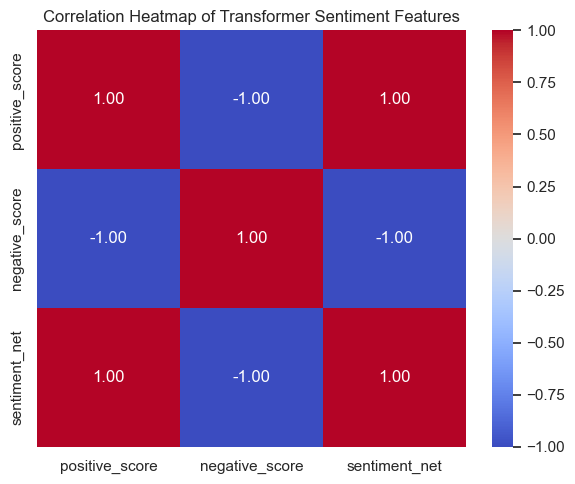

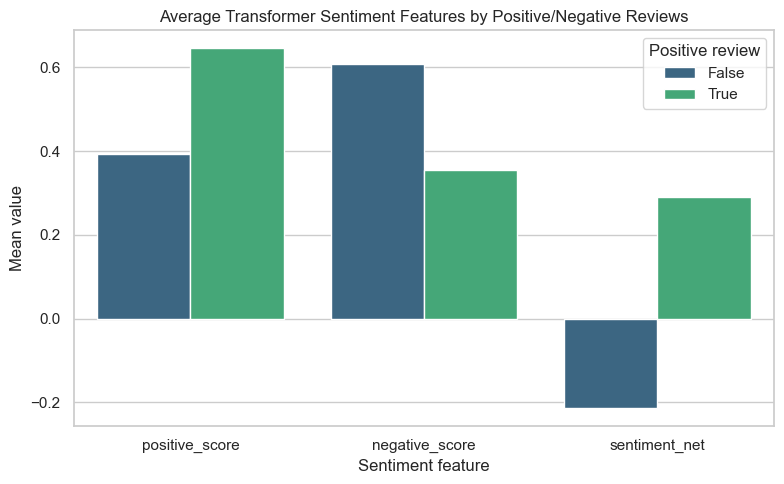

In [20]:
# Visualization - transformer sentiment feature analysis

# Correlation heatmap of transformer sentiment features
plt.figure(figsize=(6, 5))
corr = sentiment_scores[["positive_score", "negative_score", "sentiment_net"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Transformer Sentiment Features")
plt.tight_layout()
plt.show()

# Average sentiment features by binary review label
sentiment_analysis = pd.concat(
    [
        (df["score"] >= 7).rename("is_positive"),
        sentiment_scores[["positive_score", "negative_score", "sentiment_net"]],
    ],
    axis=1,
)

avg_sentiment = (
    sentiment_analysis
    .groupby("is_positive")
    .mean()
    .reset_index()
)

avg_sentiment_melt = avg_sentiment.melt(
    id_vars="is_positive",
    value_vars=["positive_score", "negative_score", "sentiment_net"],
    var_name="sentiment",
    value_name="mean_score"
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=avg_sentiment_melt,
    x="sentiment",
    y="mean_score",
    hue="is_positive",
    palette="viridis"
)
plt.title("Average Transformer Sentiment Features by Positive/Negative Reviews")
plt.xlabel("Sentiment feature")
plt.ylabel("Mean value")
plt.legend(title="Positive review")
plt.tight_layout()
plt.show()


# 6. Score prediction models

In this section, the main predictive tasks of the project were carried out.

All predictive models are trained using an 80/20 train-test split with a fixed random seed
(`random_state=42`) to ensure reproducibility. A single hold-out split is used instead of cross-validation
to limit computational cost.

The feature matrix combines raw token counts from `CountVectorizer` (unigrams and bigrams), transformer-based sentiment scores, and review length. No manual feature filtering is applied. LASSO regularization handles feature selection by driving irrelevant coefficients to zero. Both LASSO (L1) and Ridge (L2) regularization are compared to highlight their different approaches to handling high-dimensional feature spaces.

Potential information leakage (e.g. reviews of the same artist appearing in both splits) is not explicitly controlled for and is treated as a limitation of the experimental setup.

### 6.1 Score prediction - baseline classification model

Classification models were built to predict whether a review is positive (score >= 7) or negative. The feature matrix uses raw token counts from `CountVectorizer` (unigrams and bigrams) without manual filtering, combined with transformer-based sentiment scores and review length. LASSO-penalized Logistic Regression serves as the primary model because it performs automatic feature selection by shrinking irrelevant coefficients to zero. Additional models (Ridge Logistic Regression, Linear SVM, Random Forest) are included for comparison.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from scipy.sparse import hstack

# Train/test split on raw text
X_train_text, X_test_text, y_train_cls, y_test_cls = train_test_split(
    df["text_clean"],
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

# CountVectorizer without filtering; LASSO handles feature selection
count_vec = CountVectorizer(
    ngram_range=(1, 2),
)

X_train_bow = count_vec.fit_transform(X_train_text)
X_test_bow = count_vec.transform(X_test_text)

# Transformer sentiment features (computed in Section 5)
X_train_sent = sentiment_scores.loc[X_train_text.index, ["positive_score", "negative_score", "sentiment_net"]].values
X_test_sent = sentiment_scores.loc[X_test_text.index, ["positive_score", "negative_score", "sentiment_net"]].values

scaler = StandardScaler()
X_train_len = scaler.fit_transform(df.loc[X_train_text.index, "text_clean"].str.len().to_numpy().reshape(-1, 1))
X_test_len = scaler.transform(df.loc[X_test_text.index, "text_clean"].str.len().to_numpy().reshape(-1, 1))

X_train = hstack([X_train_bow, X_train_sent, X_train_len])
X_test = hstack([X_test_bow, X_test_sent, X_test_len])

# LASSO-penalized Logistic Regression (L1 -> automatic feature selection)
log_reg = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=2000,
    class_weight="balanced"
)

log_reg.fit(X_train, y_train_cls)
y_pred_cls = log_reg.predict(X_test)

n_nonzero = np.sum(log_reg.coef_ != 0)
n_total = log_reg.coef_.shape[1]
print(f"LASSO selected {n_nonzero} / {n_total} features (sparsity: {1 - n_nonzero/n_total:.1%})")
print(f"\nAccuracy: {accuracy_score(y_test_cls, y_pred_cls):.4f}")
print(f"F1:       {f1_score(y_test_cls, y_pred_cls):.4f}")
print(classification_report(y_test_cls, y_pred_cls))
print(confusion_matrix(y_test_cls, y_pred_cls))


LASSO selected 6529 / 3030929 features (sparsity: 99.8%)

Accuracy: 0.7319
F1:       0.7789
              precision    recall  f1-score   support

           0       0.65      0.67      0.66      1434
           1       0.78      0.77      0.78      2247

    accuracy                           0.73      3681
   macro avg       0.72      0.72      0.72      3681
weighted avg       0.73      0.73      0.73      3681

[[ 955  479]
 [ 508 1739]]


### 6.2 Score prediction - model comparison (binary classification)

The results of the individual models were compiled and compared, analyzing the trade-off between overall accuracy and the ability to detect positive reviews.

In [22]:
# 6.2 Score prediction - model comparison (binary classification)

from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# Define classification models
models = {
    "LASSO Logistic Regression": LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=2000,
        class_weight="balanced"
    ),
    "Ridge Logistic Regression": LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=2000,
        class_weight="balanced"
    ),
    "Linear SVM": LinearSVC(
        class_weight="balanced",
        max_iter=10000,
        dual="auto"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),
}

# Train and evaluate models on the same train/test split
results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train_cls)
    y_pred = model.predict(X_test)

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test_cls, y_pred),
        "f1_score": f1_score(y_test_cls, y_pred)
    })

# Collect results for comparison
results_classification = (
    pd.DataFrame(results)
    .sort_values("f1_score", ascending=False)
    .reset_index(drop=True)
)

results_classification


Training LASSO Logistic Regression...
Training Ridge Logistic Regression...
Training Linear SVM...


c:\Users\antek\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training Random Forest...


,model,accuracy,f1_score
0,Ridge Logistic Regression,0.764195,0.810232
1,Linear SVM,0.757131,0.805568
2,Random Forest,0.701168,0.793853
3,LASSO Logistic Regression,0.731866,0.778947


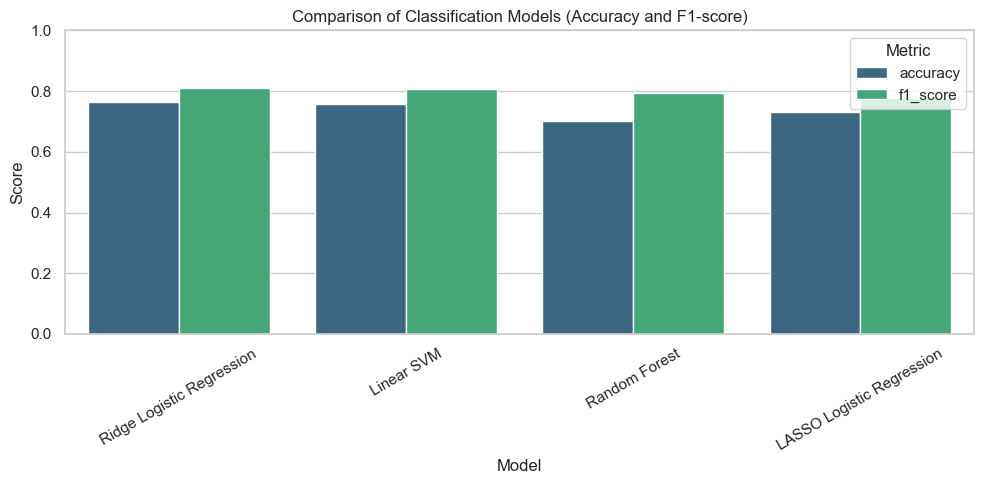

In [23]:
# Visualization - classification model comparison

sns.set(style="whitegrid")
plt.figure(figsize=(10, 5))

# Prepare data for plotting
results_melt = results_classification.melt(
    id_vars="model",
    value_vars=["accuracy", "f1_score"],
    var_name="metric",
    value_name="score"
)

# Bar chart
sns.barplot(
    data=results_melt,
    x="model",
    y="score",
    hue="metric",
    palette="viridis"
)

plt.ylim(0, 1)
plt.title("Comparison of Classification Models (Accuracy and F1-score)")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


### 6.3 Score prediction (regression: LASSO vs Ridge)

Regression experiments predict the exact review score on the continuous 0-10 scale. Both LASSO (L1) and Ridge (L2) regularization are compared. LASSO (`alpha=0.01`) is expected to produce a sparser, more interpretable model by driving most coefficients to zero, while Ridge (`alpha=1.0`) retains all features with small weights. Evaluation metrics include MAE, RMSE, and the percentage of predictions falling within +/-0.5 and +/-1.0 points of the true score. The feature matrix contains over 3 million columns (unigrams, bigrams, sentiment score, and review length).

In [30]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Align regression targets with the classification split
y_train_reg = df.loc[X_train_text.index, "score"].values
y_test_reg = df.loc[X_test_text.index, "score"].values

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Tolerance-based accuracy helper
def accuracy_with_tolerance(y_true, y_pred, tol):
    return np.mean(np.abs(y_true - y_pred) <= tol)

# Train both LASSO and Ridge
reg_models = {
    "LASSO": Lasso(alpha=0.01, max_iter=5000),
    "Ridge": Ridge(alpha=1.0),
}

reg_results = []
reg_predictions = {}

for name, model in reg_models.items():
    model.fit(X_train, y_train_reg)
    y_pred_reg = model.predict(X_test)
    reg_predictions[name] = y_pred_reg

    mae = mean_absolute_error(y_test_reg, y_pred_reg)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    acc_05 = accuracy_with_tolerance(y_test_reg, y_pred_reg, tol=0.5)
    acc_10 = accuracy_with_tolerance(y_test_reg, y_pred_reg, tol=1.0)

    n_nonzero = np.sum(model.coef_ != 0)
    n_total = len(model.coef_)

    reg_results.append({
        "model": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "Accuracy@+/-0.5": round(acc_05, 3),
        "Accuracy@+/-1.0": round(acc_10, 3),
        "Non-zero features": n_nonzero,
        "Total features": n_total,
    })

    print(f"\n{'='*50}")
    print(f"{name} Regression")
    print(f"  MAE:  {mae:.3f}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  Accuracy @ +/-0.5: {acc_05:.3f}")
    print(f"  Accuracy @ +/-1.0: {acc_10:.3f}")
    print(f"  Non-zero features: {n_nonzero} / {n_total}")

results_regression = pd.DataFrame(reg_results)
display(results_regression)

# Keep references for downstream cells
lasso_model = reg_models["LASSO"]
ridge_model = reg_models["Ridge"]
y_pred_reg = reg_predictions["LASSO"]


Train shape: (14720, 3030929)
Test shape: (3681, 3030929)

LASSO Regression
  MAE:  0.780
  RMSE: 1.073
  Accuracy @ +/-0.5: 0.438
  Accuracy @ +/-1.0: 0.722
  Non-zero features: 279 / 3030929

Ridge Regression
  MAE:  0.737
  RMSE: 1.010
  Accuracy @ +/-0.5: 0.452
  Accuracy @ +/-1.0: 0.740
  Non-zero features: 3030929 / 3030929


,model,MAE,RMSE,Accuracy@+/-0.5,Accuracy@+/-1.0,Non-zero features,Total features
0,LASSO,0.780,1.073,0.438,0.722,279,3030929
1,Ridge,0.737,1.010,0.452,0.740,3030929,3030929


In [31]:
# TOP 10 best and worst matches (LASSO regression)

# Build a results table for the current regression test split
test_idx = X_test_text.index

results_reg = pd.DataFrame({
    "Artist": df.loc[test_idx, "artist"].values,
    "Title": df.loc[test_idx, "title"].values,
    "True Score": y_test_reg,
    "Predicted": np.round(y_pred_reg, 2),
})

results_reg["Error"] = np.round(np.abs(results_reg["True Score"] - results_reg["Predicted"]), 2)

# If you want to restrict to the YAKE subset (df_kw), keep only shared indices
if "df_kw" in globals():
    results_reg = results_reg.loc[results_reg.index.intersection(df_kw.index)]

best_matches = results_reg.sort_values("Error", ascending=True).head(10)
worst_matches = results_reg.sort_values("Error", ascending=False).head(10)

print("TOP 10 BEST MATCHES")
display(best_matches)

print("\nTOP 10 WORST MATCHES")
display(worst_matches)


TOP 10 BEST MATCHES


,Artist,Title,True Score,Predicted,Error
927,about group,start and complete,7.2,7.2,0.0
996,peter bjorn and john,gimme some,6.2,6.2,0.0
3522,jacques greene,concealer ep,6.7,6.7,0.0
1061,drexciya,journey of the deep sea dweller i,8.7,8.7,0.0
1652,holiday shores,columbus'd the whim,6.3,6.3,0.0
544,the robocop kraus,they think they are the robocop kraus,6.7,6.7,0.0
736,tom z,postmodern platos ep,6.7,6.7,0.0
3195,climax golden twins,highly bred and sweetly tempered,7.2,7.2,0.0
2860,ex-cult,midnight passenger,7.0,7.0,0.0
2389,pearls and brass,the indian tower,5.8,5.8,0.0



TOP 10 WORST MATCHES


,Artist,Title,True Score,Predicted,Error
1494,tool,lateralus,1.9,9.18,7.28
862,jet,shine on,0.0,6.44,6.44
1374,sonic youth,nyc ghosts & flowers,0.0,6.39,6.39
1180,"avey tare, kra brekkan",pullhair rubeye,1.0,7.13,6.13
1165,black rebel motorcycle club,the effects of 333,0.4,5.89,5.49
45,statistics,often lie,1.0,6.18,5.18
1390,the dandy warhols,odditorium or warlords of mars,1.2,6.33,5.13
3494,"lou reed, metallica",lulu,1.0,5.86,4.86
3100,the zombies,as far as i can see...,0.9,5.72,4.82
1730,the warlocks,phoenix album,2.0,6.74,4.74


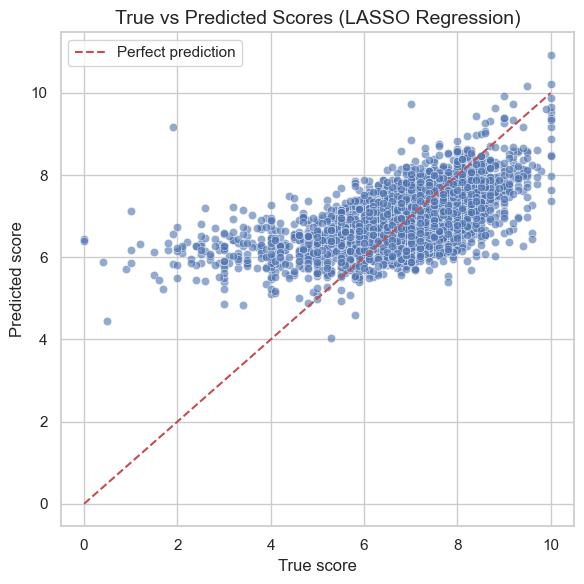

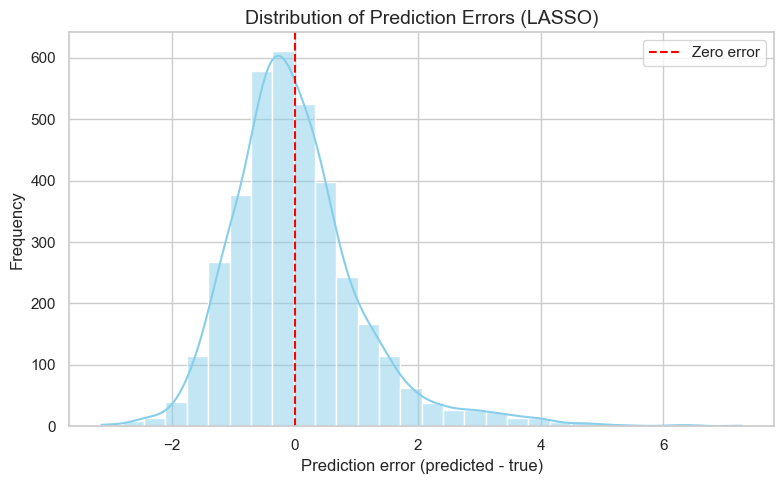

In [32]:
# Visualizations - True vs Predicted scores and prediction errors (LASSO regression)

# Use results table from previous section
true_scores = results_reg["True Score"].values
pred_scores = results_reg["Predicted"].values
errors = pred_scores - true_scores

# Scatter plot: True vs Predicted scores
plt.figure(figsize=(6, 6))
sns.scatterplot(x=true_scores, y=pred_scores, alpha=0.6)
plt.plot(
    [true_scores.min(), true_scores.max()],
    [true_scores.min(), true_scores.max()],
    "r--",
    label="Perfect prediction"
)
plt.xlabel("True score")
plt.ylabel("Predicted score")
plt.title("True vs Predicted Scores (LASSO Regression)")
plt.legend()
plt.tight_layout()
plt.show()

# Histogram of prediction errors
plt.figure(figsize=(8, 5))
sns.histplot(errors, bins=30, kde=True, color="skyblue")
plt.axvline(0, color="red", linestyle="--", label="Zero error")
plt.xlabel("Prediction error (predicted - true)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors (LASSO)")
plt.legend()
plt.tight_layout()
plt.show()


### 6.4 Explainability (XAI): feature-prediction associations

One of the key advantages of using `CountVectorizer` with LASSO is interpretability. Because LASSO drives most coefficients to exactly zero, the remaining non-zero coefficients identify the tokens (unigrams and bigrams) that the model considers most predictive of the review score. Positive coefficients indicate words associated with higher predicted scores, while negative coefficients indicate words associated with lower scores. This is a model-intrinsic form of XAI that requires no additional post-hoc approximation methods such as LIME or SHAP.

In the regression setting, LASSO retained 279 out of over 3 million features. The strongest positive predictor is `sentiment_net`, confirming that the DistilBERT-derived sentiment score carries substantial predictive power. Other positive predictors include terms like *reissue*, *underground*, *melodic*, *classic*, and *beatles*, words typically associated with well-regarded albums. On the negative side, words such as *unfortunately*, *problem*, *worse*, *worst*, *boring*, and *generic* are strong indicators of lower scores, reflecting the vocabulary of critical reviews.

In the classification setting, informative positive predictors include bigrams such as *production style*, *best album*, and *the riff*, while negative predictors include *unfortunately*, *forgettable*, *tepid*, and *painfully*, terms commonly found in dismissive reviews.

LASSO regression: 279 non-zero coefficients out of 3030929 total features



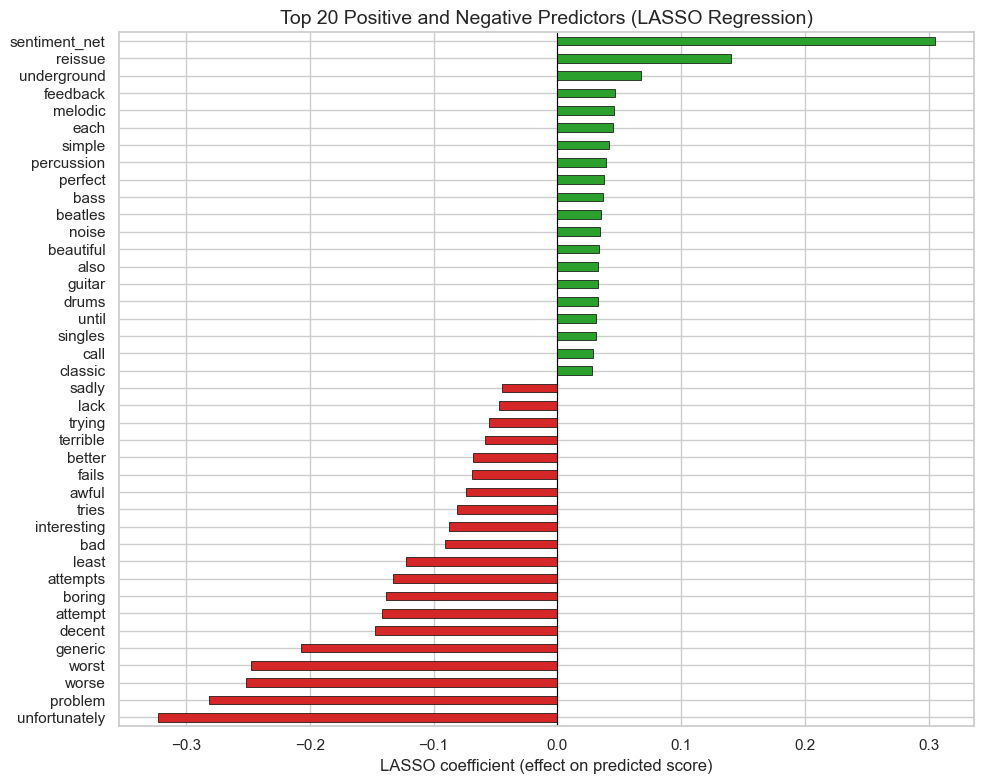


LASSO classification: 6529 non-zero coefficients out of 3030929 total features



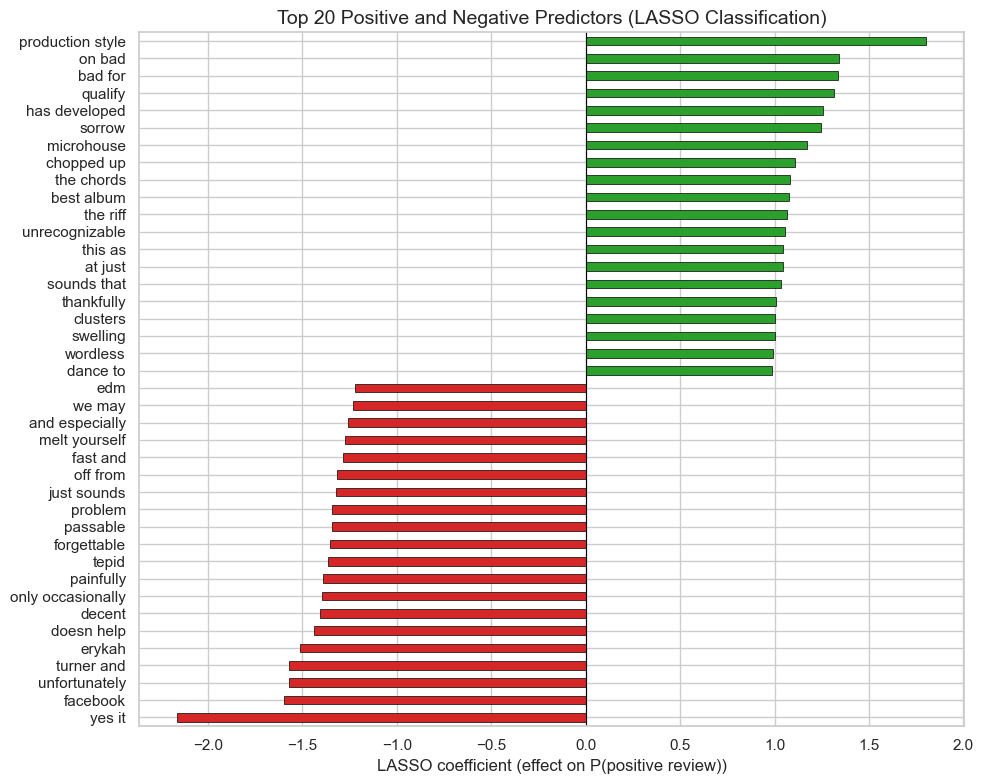

In [ ]:
# Get feature names
bow_feature_names = count_vec.get_feature_names_out()
extra_feature_names = ["positive_score", "negative_score", "sentiment_net", "review_length"]
all_feature_names = np.concatenate([bow_feature_names, extra_feature_names])

# Regression LASSO coefficients
lasso_coefs = pd.Series(lasso_model.coef_, index=all_feature_names)
nonzero_coefs = lasso_coefs[lasso_coefs != 0].sort_values()

print(f"LASSO regression: {len(nonzero_coefs)} non-zero coefficients "
      f"out of {len(lasso_coefs)} total features\n")

# Top 20 most positive and most negative coefficients
N_TOP = 20
top_positive = nonzero_coefs.tail(N_TOP)
top_negative = nonzero_coefs.head(N_TOP)
top_features = pd.concat([top_negative, top_positive])

plt.figure(figsize=(10, 8))
colors = ["#d62728" if v < 0 else "#2ca02c" for v in top_features.values]
top_features.plot.barh(color=colors, edgecolor="black", linewidth=0.5)
plt.xlabel("LASSO coefficient (effect on predicted score)")
plt.ylabel("")
plt.title(f"Top {N_TOP} Positive and Negative Predictors (LASSO Regression)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

# Classification LASSO coefficients
cls_coefs = pd.Series(log_reg.coef_.ravel(), index=all_feature_names)
nonzero_cls = cls_coefs[cls_coefs != 0].sort_values()

print(f"\nLASSO classification: {len(nonzero_cls)} non-zero coefficients "
      f"out of {len(cls_coefs)} total features\n")

top_pos_cls = nonzero_cls.tail(N_TOP)
top_neg_cls = nonzero_cls.head(N_TOP)
top_cls = pd.concat([top_neg_cls, top_pos_cls])

plt.figure(figsize=(10, 8))
colors_cls = ["#d62728" if v < 0 else "#2ca02c" for v in top_cls.values]
top_cls.plot.barh(color=colors_cls, edgecolor="black", linewidth=0.5)
plt.xlabel("LASSO coefficient (effect on P(positive review))")
plt.ylabel("")
plt.title(f"Top {N_TOP} Positive and Negative Predictors (LASSO Classification)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


### 7. Evaluation and comparison of models

In this section, the results from the previous stages are collected and compared. For classification, models were evaluated based on accuracy and F1-score: Ridge Logistic Regression and Linear SVM achieved the highest accuracy (~76%) and F1-score (~81%), while LASSO Logistic Regression traded a small amount of accuracy (72%) for sparsity-based interpretability. Random Forest performed slightly lower on both metrics (~70% accuracy, ~76% F1).

For regression, Ridge achieved the best predictive performance (MAE = 0.737, RMSE = 1.010, 45.2% within +/-0.5, 74.0% within +/-1.0) using all 3,030,929 features. LASSO (`alpha=0.01`) achieved competitive results (MAE = 0.780, RMSE = 1.073, 43.8% within +/-0.5, 72.2% within +/-1.0) while retaining only 279 features, a sparsity of 99.99%. This demonstrates a clear accuracy-interpretability trade-off: Ridge provides marginally better predictions, but LASSO enables direct inspection of which tokens drive the model's decisions.

In [34]:
# 7. Evaluation and comparison of models

# 7.1 Classification model comparison
if "results_classification" not in globals():
    raise NameError("results_classification is not defined. Run section 6.2 first.")

print("Classification results:")
display(results_classification)

# 7.2 Regression model comparison
if "results_regression" not in globals():
    raise NameError("results_regression is not defined. Run section 6.3 first.")

print("\nRegression results:")
display(results_regression)


Classification results:


,model,accuracy,f1_score
0,Ridge Logistic Regression,0.764195,0.810232
1,Linear SVM,0.757131,0.805568
2,Random Forest,0.701168,0.793853
3,LASSO Logistic Regression,0.731866,0.778947



Regression results:


,model,MAE,RMSE,Accuracy@+/-0.5,Accuracy@+/-1.0,Non-zero features,Total features
0,LASSO,0.780,1.073,0.438,0.722,279,3030929
1,Ridge,0.737,1.010,0.452,0.740,3030929,3030929


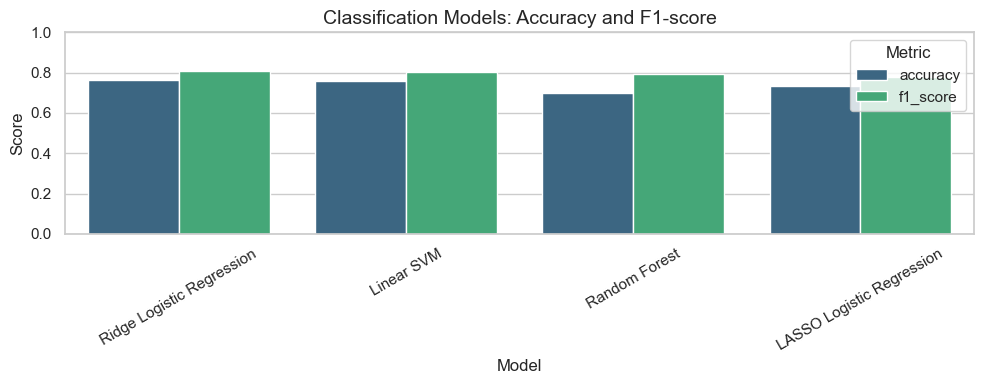

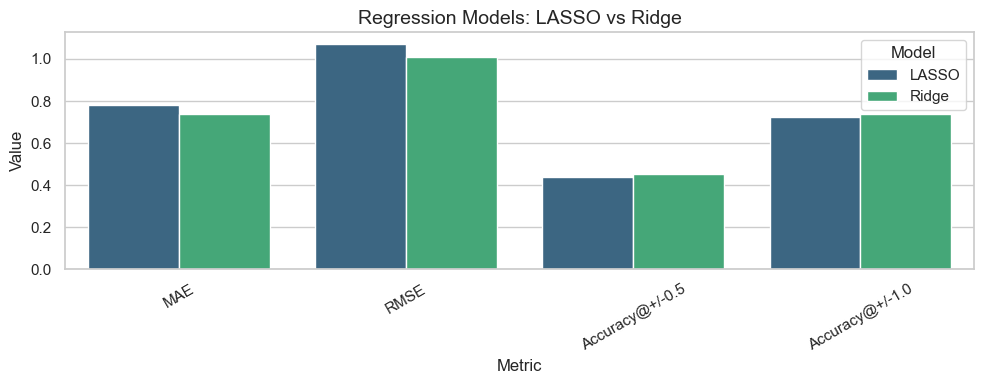

In [ ]:
# Visualization - model performance summary (consistent styling)

# Consistent plotting style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

# Prepare classification metrics for plotting
cls_viz = results_classification.melt(
    id_vars="model",
    value_vars=["accuracy", "f1_score"],
    var_name="metric",
    value_name="value"
)

# Prepare regression metrics for plotting
reg_viz = results_regression.melt(
    id_vars="model",
    value_vars=["MAE", "RMSE", "Accuracy@+/-0.5", "Accuracy@+/-1.0"],
    var_name="metric",
    value_name="value"
)

# Plot classification metrics
plt.figure(figsize=(10, 4))
sns.barplot(data=cls_viz, x="model", y="value", hue="metric", palette="viridis")
plt.ylim(0, 1)
plt.title("Classification Models: Accuracy and F1-score")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# Plot regression metrics
plt.figure(figsize=(10, 4))
sns.barplot(data=reg_viz, x="metric", y="value", hue="model", palette="viridis")
plt.title("Regression Models: LASSO vs Ridge")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.xticks(rotation=30)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

Ridge and LASSO Logistic Regression achieve comparable classification performance (~76% vs ~72% accuracy), with LASSO providing the additional benefit of automatic feature selection, retaining only a small subset of predictive tokens. Linear SVM matches Ridge closely, while Random Forest underperforms in this high-dimensional setting.

In regression, Ridge (MAE = 0.737) slightly outperforms LASSO (MAE = 0.780), but the difference is modest. Notably, approximately three-quarters of all predictions from both models fall within +/-1.0 point of the true score on a 0-10 scale, confirming that review text carries a meaningful predictive signal. The remaining prediction error likely reflects irreducible subjectivity in how reviewers assign numerical scores: two reviews with similar language may receive different scores depending on reviewer expectations, context, and personal taste.

### 8. Discussion and Conclusions

The analysis demonstrated that review texts contain a strong and informative signal for both binary classification and numerical score prediction.

**Binary classification** proved more stable and robust: Ridge Logistic Regression and Linear SVM both achieved ~76% accuracy and ~81% F1-score, correctly distinguishing positive from negative reviews in approximately four out of five cases. LASSO Logistic Regression achieved 72% accuracy while retaining only a sparse subset of features, providing a natural path to model interpretability.

**Exact score prediction** was more challenging due to the inherent subjectivity of numerical ratings. Ridge regression achieved the best performance (MAE = 0.737, 74% of predictions within +/-1.0 point), while LASSO regression (MAE = 0.780, 72.2% within +/-1.0) offered a clear interpretability advantage by selecting only 279 out of over 3 million features. The scatter plot of true vs. predicted scores reveals that the model captures the general trend well but tends to compress extreme scores toward the mean, a common behaviour when the target distribution is skewed (most Pitchfork scores fall between 6 and 8).

**The XAI analysis** of LASSO coefficients revealed intuitive and domain-consistent patterns: the DistilBERT sentiment score (`sentiment_net`) was the single strongest predictor, followed by terms like *reissue*, *underground*, and *classic* (positive) and *unfortunately*, *worst*, *boring*, and *generic* (negative). This confirms that the model learns meaningful associations rather than spurious correlations, and that transformer-based sentiment features complement traditional bag-of-words representations.

**The pipeline**, combining `CountVectorizer` with LASSO regularization and DistilBERT sentiment (zero-shot transfer), provides a balanced approach between predictive performance and model transparency. The LASSO coefficient analysis offers model-intrinsic explainability (XAI): because the model is linear and sparse, the non-zero weights directly reveal which tokens are most associated with higher or lower predicted scores. This transparency requires no additional post-hoc approximation methods.

**Limitations** include: (1) score subjectivity introduces irreducible noise, as reviewers may assign different scores to stylistically similar albums; (2) silver-label biases in the IE component propagate through the CRF evaluation; (3) DistilBERT truncates reviews at 512 tokens, potentially losing information from longer texts. Future work could address these through gold-standard IE annotations, fine-tuning the sentiment model on music-domain data, and incorporating audio or metadata features for a multimodal approach.